In [4]:
# Importing Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import librosa  # Used for audio analysis
import librosa.display
from glob import glob # Used for file handling
import IPython.display as ipd # Interactive audio playback

# Libraries used for analysis
import statsmodels.api as sm
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
# loading the dataset

audio_dir=glob("/content/drive/MyDrive/Hindi_fem_mono/Hindi_fem_audio/*.wav")
audio_file = sorted(audio_dir)

In [7]:
# play a file

ipd.Audio(audio_file[2])

# Basic EDA

In [8]:
# load the audio cell file
# y will contain the raw audio time series data
# sr will be the sample rate

y,sr = librosa.load(audio_file[2])

In [9]:
# display the first 10 samples of the raw audio data
print(f'the first 10 samples of y is {y[:10]}')
# Display the shape of the audio data array
print(f"Shape of y (audio data): {y.shape}")

# Display the sample rate of the audio
print(f"Sample rate: {sr} Hz")

the first 10 samples of y is [-1.4012909e-05  8.9582920e-07 -9.1765742e-06 -2.4880851e-06
  1.5019210e-05  1.0491634e-05 -4.4989625e-05 -5.4112879e-06
 -1.2322516e-06  3.0269127e-06]
Shape of y (audio data): (89011,)
Sample rate: 22050 Hz


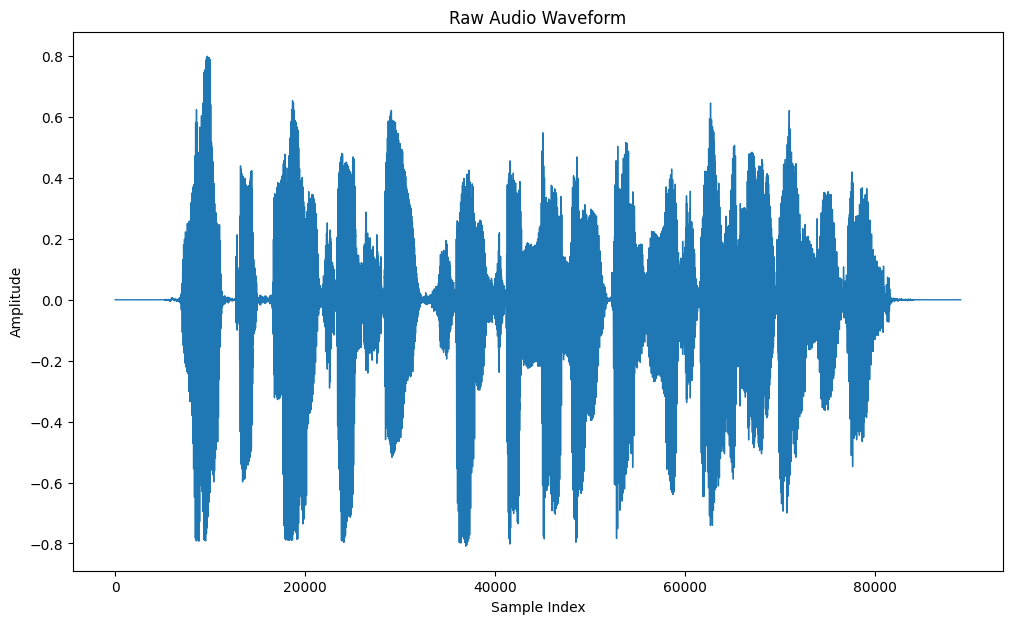

In [10]:
# Plot the raw audio waveform
pd.Series(y).plot(
    figsize=(12, 7),             # Set the figure size for better visibility
    lw=1,                       # Line width for the waveform
    title="Raw Audio Waveform", # Title of the plot        # Set the color using the predefined palette
    xlabel="Sample Index",      # Label for the x-axis
    ylabel="Amplitude"          # Label for the y-axis
)
plt.show()

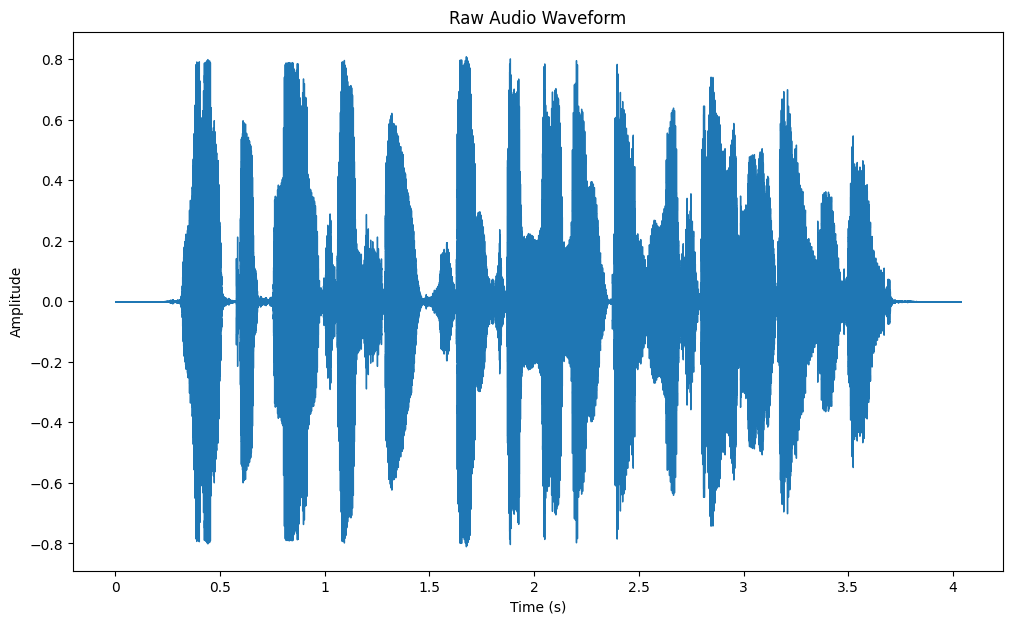

In [11]:
plt.figure(figsize=(12,7))
# Reload y and sr to ensure they refer to the audio data for plotting
y, sr = librosa.load(audio_file[2])
librosa.display.waveshow(y=y, sr=sr)
plt.title('Raw Audio Waveform')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.show()

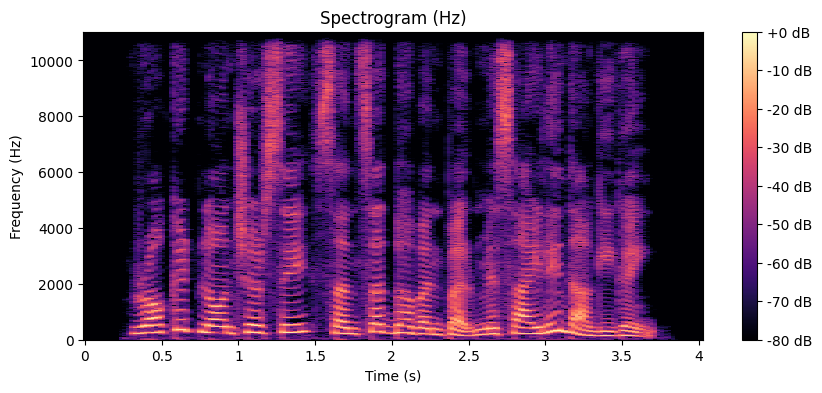

In [12]:
stft = librosa.stft(y)  # Short-time Fourier Transform
spectrogram = librosa.amplitude_to_db(np.abs(stft), ref=np.max)
plt.figure(figsize=(10,4))
librosa.display.specshow(spectrogram, sr=sr, x_axis='time', y_axis='linear')
plt.colorbar(format="%+2.f dB")
plt.title('Spectrogram (Hz)')
plt.xlabel('Time (s)')
plt.ylabel('Frequency (Hz)')
plt.show()

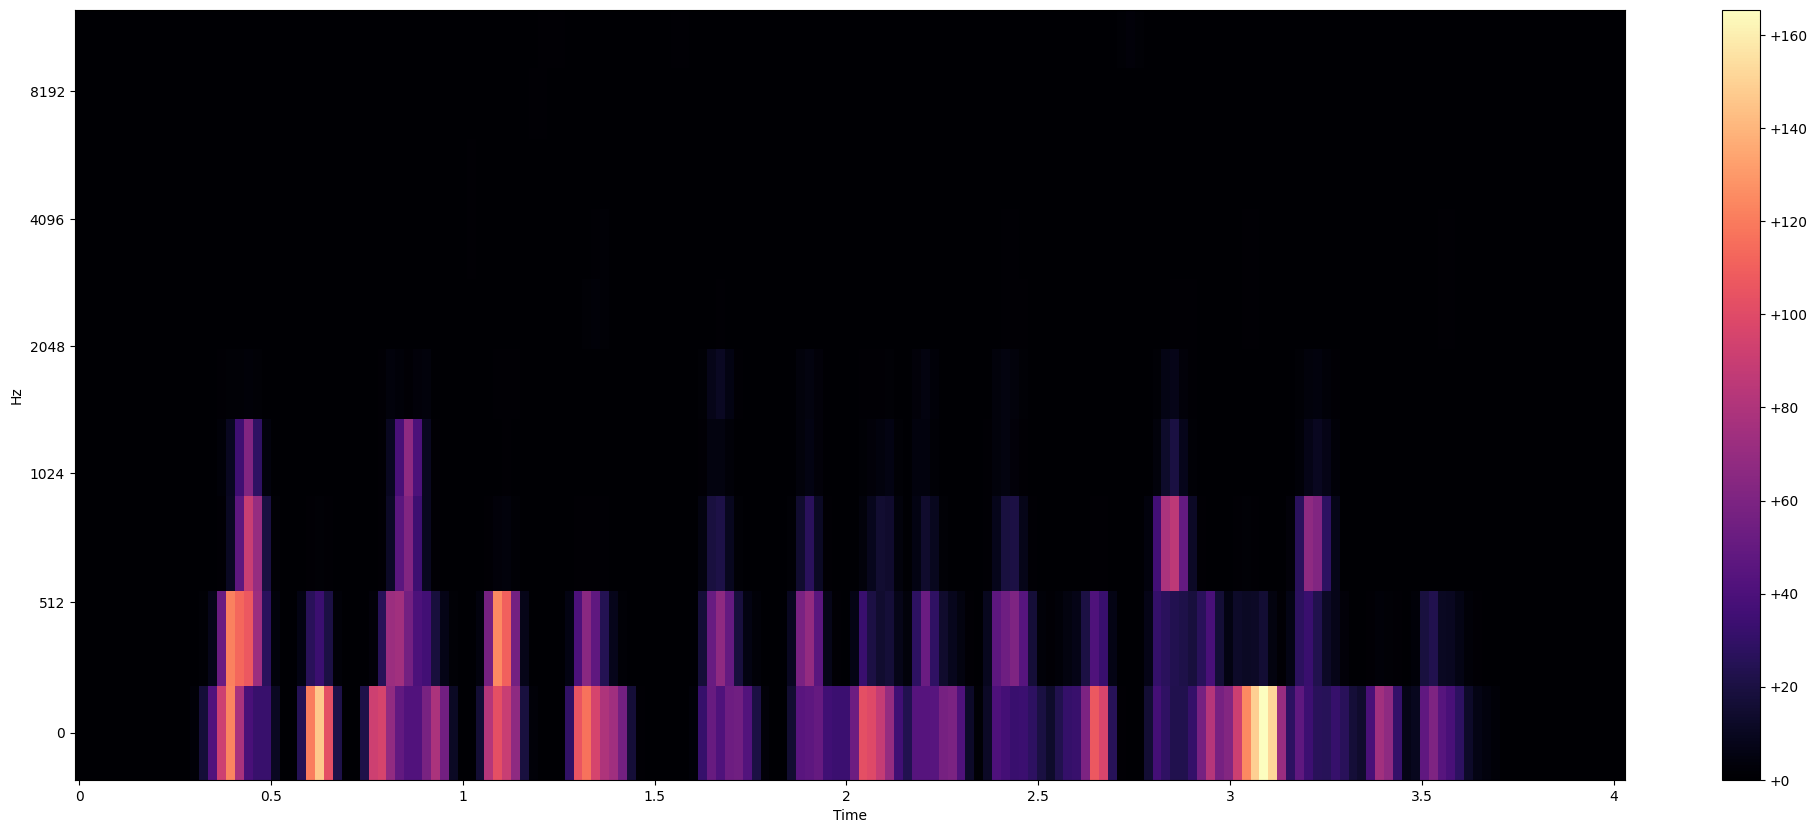

In [13]:
# Extracting the Mel spectrogram

mel_spectrogram = librosa.feature.melspectrogram(y=y, sr=sr, n_fft=2048, hop_length=512, n_mels=10)
plt.figure(figsize=(25, 10))
librosa.display.specshow(mel_spectrogram, x_axis="time", y_axis="mel", sr=sr)
plt.colorbar(format="%+2.f")
plt.show()

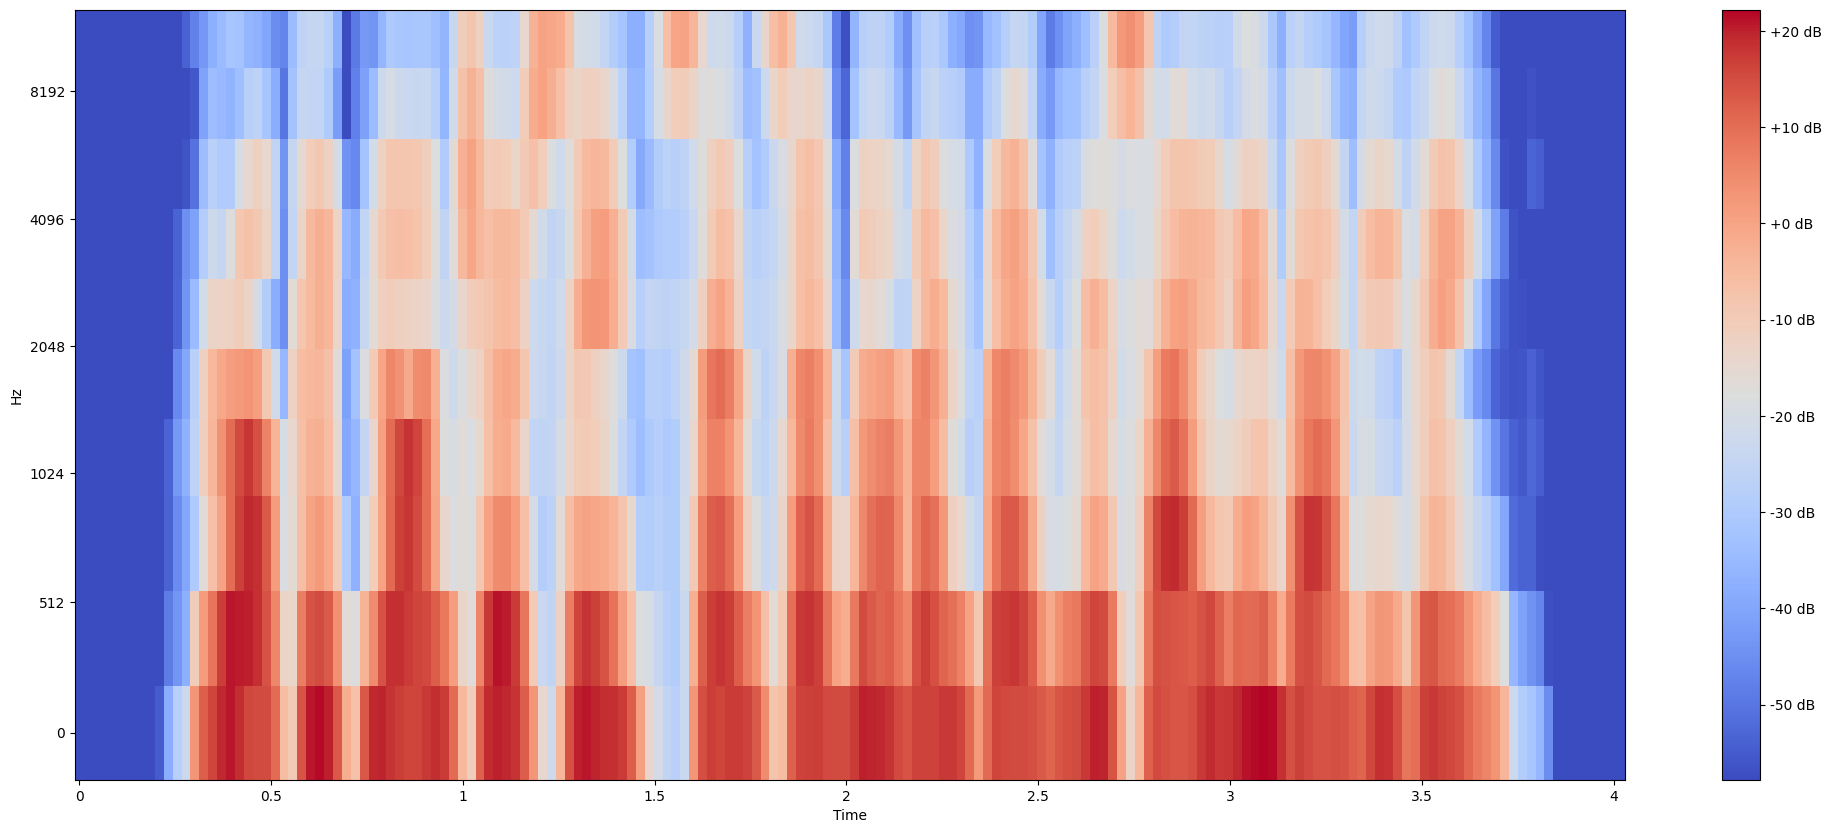

In [14]:
# Extracting the log mel spectrogram

log_mel_spectrogram = librosa.power_to_db(mel_spectrogram)
plt.figure(figsize=(25, 10))
librosa.display.specshow(log_mel_spectrogram, x_axis="time", y_axis="mel", sr=sr)
plt.colorbar(format="%+2.f dB") # Added 'dB' to label for clarity
plt.show()

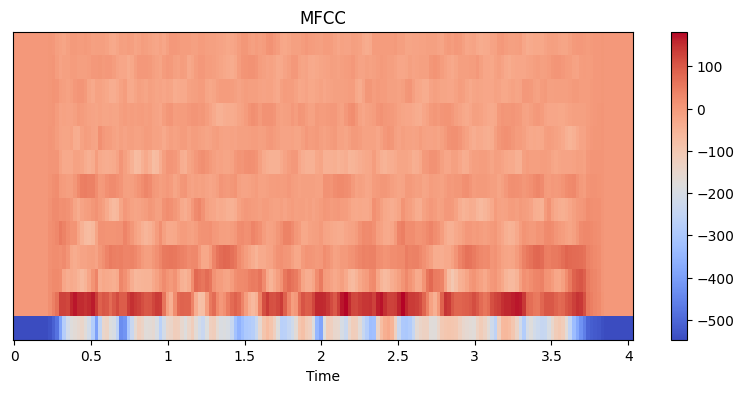

In [15]:
# Extracting MFCCs
mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
plt.figure(figsize=(10, 4))
librosa.display.specshow(mfcc, x_axis='time', sr=sr)
plt.colorbar()
plt.title('MFCC')

plt.show()

In [16]:
# tabular form of mfcc
pd.DataFrame(mfcc)

,0,1,2,3,4,5,6,7,8,9,...,164,165,166,167,168,169,170,171,172,173
0,-546.900452,-546.900452,-546.900452,-546.900452,-546.900452,-546.900452,-546.900452,-546.900452,-546.900452,-546.668213,...,-528.113586,-540.954529,-546.900452,-546.900452,-546.900452,-546.900452,-546.900452,-546.900452,-546.900452,-546.900452
1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.327683,...,25.863556,8.372007,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.325296,...,24.091255,8.262277,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.321333,...,21.349644,8.081861,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.315815,...,17.855145,7.834398,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
5,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.308772,...,14.245348,7.524850,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
6,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.300241,...,10.623211,7.159367,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
7,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.290269,...,7.439445,6.745142,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
8,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.278914,...,5.008822,6.290214,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
9,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.266225,...,3.179526,5.803280,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [17]:
# Extracting MFCCs for all files

def extract_features(directory):
  features_list = []

  audio_dir = glob(directory)

  for file in audio_dir:
    y, sr = librosa.load(file, sr = None)
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
    mfcc_scaled = np.mean(mfcc.T, axis=0)
    duration = librosa.get_duration(y=y, sr=sr)
    data = {'filename': file, 'duration': duration}

    for i, val in enumerate(mfcc_scaled):
      data[f'mfcc_{i+1}'] = val
    features_list.append(data)
  return pd.DataFrame(features_list)

In [18]:
mfcc_df = extract_features("/content/drive/MyDrive/Hindi_fem_mono/Hindi_fem_audio/*.wav")

In [19]:
mfcc_df

,filename,duration,mfcc_1,mfcc_2,mfcc_3,mfcc_4,mfcc_5,mfcc_6,mfcc_7,mfcc_8,mfcc_9,mfcc_10,mfcc_11,mfcc_12,mfcc_13
0,/content/drive/MyDrive/Hindi_fem_mono/Hindi_fe...,5.758333,-300.327148,120.928345,-8.470559,23.645855,11.628465,-4.023071,-13.230467,6.711937,-3.846221,-20.326078,-9.373515,-10.955910,-7.583772
1,/content/drive/MyDrive/Hindi_fem_mono/Hindi_fe...,5.169896,-319.762177,115.137024,-8.119379,32.418743,17.815903,6.838310,-14.974553,-0.696236,-0.812561,-23.608517,-11.847006,-7.908370,-6.495355
2,/content/drive/MyDrive/Hindi_fem_mono/Hindi_fe...,4.716750,-301.677856,114.540085,-8.549463,26.512072,8.402750,3.802257,-11.152637,3.785805,-3.413177,-18.098787,-7.639075,-9.381778,-7.356301
3,/content/drive/MyDrive/Hindi_fem_mono/Hindi_fe...,5.005562,-295.948730,106.224686,-5.951683,32.565342,7.710200,3.370178,-18.667355,7.754349,-4.159970,-21.265152,-5.600014,-10.249454,-11.527534
4,/content/drive/MyDrive/Hindi_fem_mono/Hindi_fe...,4.383125,-296.065399,120.751427,-12.603089,24.294432,3.178400,1.775096,-14.550765,5.478156,1.776956,-21.834351,-8.576143,-8.437534,-10.117886
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4581,/content/drive/MyDrive/Hindi_fem_mono/Hindi_fe...,5.734375,-296.182678,114.870644,-15.997050,36.720207,11.903413,-1.377358,-21.717293,13.531311,-2.630861,-16.489603,-4.153925,-7.671080,-6.804666
4582,/content/drive/MyDrive/Hindi_fem_mono/Hindi_fe...,3.865021,-299.020538,109.225952,-3.182021,37.190197,0.963343,0.271486,-22.236143,9.061388,-2.047005,-17.043625,-6.011830,-12.960396,-8.717494
4583,/content/drive/MyDrive/Hindi_fem_mono/Hindi_fe...,4.229604,-294.462524,94.881584,-16.818361,36.739426,0.916088,5.832238,-20.618250,8.018029,-4.829053,-11.478998,-1.284171,-9.507868,-5.682461
4584,/content/drive/MyDrive/Hindi_fem_mono/Hindi_fe...,3.599417,-297.858032,89.722687,-15.981977,42.668259,6.292518,9.690021,-20.514366,4.075935,-4.994070,-7.853026,-5.082586,-10.857638,-5.298875


# Analysis

In [20]:
mfcc_df.drop(columns=['filename']).mean()

,0
duration,5.349813
mfcc_1,-304.198914
mfcc_2,112.026276
mfcc_3,-11.472609
mfcc_4,27.720600
mfcc_5,4.816026
mfcc_6,2.630708
mfcc_7,-15.656408
mfcc_8,8.708613
mfcc_9,-3.109346


In [21]:
mfcc_df.drop(columns=['filename']).std()

,0
duration,1.233747
mfcc_1,14.629879
mfcc_2,9.457892
mfcc_3,5.875124
mfcc_4,6.478290
mfcc_5,4.950380
mfcc_6,3.816911
mfcc_7,3.817559
mfcc_8,3.614445
mfcc_9,2.825190


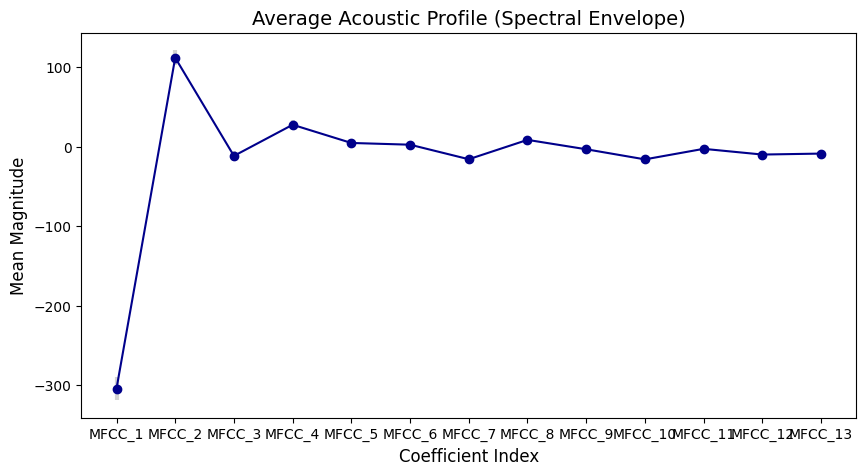

In [22]:
# Calculate mean and std for each MFCC
means = mfcc_df.filter(like='mfcc').mean()
stds = mfcc_df.filter(like='mfcc').std()

plt.figure(figsize=(10, 5))
plt.errorbar(range(1, 14), means, yerr=stds, fmt='-o', color='darkblue',
             ecolor='lightgray', elinewidth=3, capsize=0)
plt.xticks(range(1, 14), [f'MFCC_{i}' for i in range(1, 14)])
plt.title('Average Acoustic Profile (Spectral Envelope)', fontsize=14)
plt.ylabel('Mean Magnitude', fontsize=12)
plt.xlabel('Coefficient Index', fontsize=12)
plt.show()